# Tract-Level “Opportunity Desert” Metrics

**Author: Lauren Vo**

Built a tract-level dataset that combines:

- ACS demographics
- Youth-serving services (libraries, YMCA, rec centers, etc.)
- Transit stops
- Census tract geometries

to derive **“opportunity desert”** metrics.

**Ideal output schema (one row per census tract)**

- `GEOID` – Census tract ID.
- `NAME` – Tract name (from ACS / TIGER).
- `pop_total`
- `youth_5_17`, `youth_10_19`
- `youth_5_17_per_1k`, `youth_10_19_per_1k`
- `median_hh_income_2023usd`
- `households_total`, `households_zero_veh`, `zero_veh_share`
- `services_total`
- `library_count`
- `ymca_count`
- `rec_center_count`
- `youth_org_count` 
- `services_per_1k_youth_10_19`
- `services_per_1k_youth_5_17`
- `avg_distance_to_nearest_service_km`
- `distance_to_nearest_library_km`
- `distance_to_nearest_rec_center_km`
- `distance_to_nearest_ymca_km`
- `services_within_0_6mi`
- `stops_within_500m_per_tract`
- `stops_within_500m_per_1k_youth`
- `stops_within_500m_of_services`
- `desert_flag` – draft binary flag (1 = potential opportunity desert).

**Inputs used here**

(from earlier notebooks + TIGER files)

- `data/processed/acs5/2023/acs_tract_demographics_2023.csv`
- `data/processed/services/services_master_cleaned.csv`
- `data/processed/services/transit_stops_master.csv`
- TIGER tracts for CA in `data/external/tiger_tracts_2023/tl_2023_06_tract.*`

Approximate distances using straight-line (Euclidean) distance in a projected CRS.


In [52]:
# TIGER tracts for California (state FIPS 06)
shp_path = TIGER_2023_DIR / "tl_2023_06_tract.shp"
zip_path = TIGER_2023_DIR / "tl_2023_06_tract.zip"

if shp_path.exists():
    tracts_gdf = gpd.read_file(shp_path)
elif zip_path.exists():
    # read shapefile directly from the zip
    tracts_gdf = gpd.read_file(f"zip://{zip_path}")
else:
    raise FileNotFoundError(
        "Could not find tl_2023_06_tract.shp or tl_2023_06_tract.zip "
        f"in {TIGER_2023_DIR}. Make sure the TIGER tract file is there."
    )

print("Tracts (CA):", tracts_gdf.shape)
tracts_gdf.head()


Tracts (CA): (9129, 14)


,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,06,001,442700,06001442700,1400000US06001442700,4427,Census Tract 4427,G5020,S,1234016,0,+37.5371513,-122.0081095,"POLYGON ((-122.01721 37.53932, -122.01719 37.5..."
1,06,001,442800,06001442800,1400000US06001442800,4428,Census Tract 4428,G5020,S,1278646,0,+37.5293619,-121.9931002,"POLYGON ((-122.0023 37.52984, -122.00224 37.52..."
2,06,037,204920,06037204920,1400000US06037204920,2049.20,Census Tract 2049.20,G5020,S,909972,0,+34.0175004,-118.1974975,"POLYGON ((-118.20284 34.01966, -118.20283 34.0..."
3,06,037,205110,06037205110,1400000US06037205110,2051.10,Census Tract 2051.10,G5020,S,286962,0,+34.0245059,-118.2142985,"POLYGON ((-118.21964 34.02628, -118.21945 34.0..."
4,06,037,320101,06037320101,1400000US06037320101,3201.01,Census Tract 3201.01,G5020,S,680504,0,+34.2992784,-118.4326573,"POLYGON ((-118.43882 34.29911, -118.43732 34.3..."


In [53]:
# Filter to San Diego County
sd_tracts = tracts_gdf.query("STATEFP == '06' and COUNTYFP == '073'").copy()
sd_tracts = sd_tracts[["STATEFP", "COUNTYFP", "TRACTCE", "GEOID", "NAME", "geometry"]]
sd_tracts["GEOID"] = sd_tracts["GEOID"].astype(str)

print("San Diego tracts:", sd_tracts.shape)

# Join ACS demographics onto tract geometries
acs["GEOID"] = acs["GEOID"].astype(str)
sd_tracts = sd_tracts.merge(acs, on="GEOID", how="left")

sd_tracts.head()


San Diego tracts: (737, 6)


,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME_x,geometry,NAME_y,pop_total,youth_5_17,youth_10_19,youth_5_17_per_1k,youth_10_19_per_1k,median_hh_income_2023usd,households_total,households_zero_veh,zero_veh_share
0,06,073,008331,06073008331,83.31,"POLYGON ((-117.23082 32.94176, -117.23079 32.9...",Census Tract 83.31; San Diego County; California,2766.0,615.0,556.0,222.342733,201.012292,217083.0,943.0,14.0,0.014846
1,06,073,008336,06073008336,83.36,"POLYGON ((-117.13793 32.96927, -117.13792 32.9...",Census Tract 83.36; San Diego County; California,2086.0,401.0,294.0,192.233941,140.939597,197841.0,742.0,8.0,0.010782
2,06,073,008337,06073008337,83.37,"POLYGON ((-117.14678 32.95497, -117.14657 32.9...",Census Tract 83.37; San Diego County; California,4996.0,875.0,677.0,175.140112,135.508407,180496.0,1510.0,0.0,0.000000
3,06,073,011601,06073011601,116.01,"POLYGON ((-117.10356 32.6672, -117.10314 32.66...",Census Tract 116.01; San Diego County; California,5796.0,1055.0,843.0,182.022084,145.445135,69542.0,1623.0,53.0,0.032656
4,06,073,011602,06073011602,116.02,"POLYGON ((-117.10154 32.66202, -117.10133 32.6...",Census Tract 116.02; San Diego County; California,3671.0,625.0,603.0,170.253337,164.260420,57303.0,1320.0,125.0,0.094697


In [54]:
# Keep only rows with coordinates
services_geo = services.dropna(subset=["lat", "lon"]).copy()

services_geo_gdf = gpd.GeoDataFrame(
    services_geo,
    geometry=gpd.points_from_xy(services_geo["lon"], services_geo["lat"]),
    crs="EPSG:4326",
)

# Basic category flags
services_geo_gdf["is_library"] = services_geo_gdf["service_type"].eq("library")
services_geo_gdf["is_ymca"] = services_geo_gdf["org"].str.contains("YMCA", case=False, na=False)
services_geo_gdf["is_rec_center"] = services_geo_gdf["service_type"].eq("rec_center")

# "Youth org" heuristic 
youth_keywords = ["youth", "teen", "boys & girls", "bgc", "after school"]
name_lower = services_geo_gdf["name"].astype(str).str.lower()
org_lower = services_geo_gdf["org"].astype(str).str.lower()

services_geo_gdf["is_youth_org"] = False
for kw in youth_keywords:
    services_geo_gdf.loc[name_lower.str.contains(kw) | org_lower.str.contains(kw), "is_youth_org"] = True

services_geo_gdf.head()


,service_type,org,name,address,city,state,zip,lat,lon,phone,fax,website,hours,eligibility,source,park_name,sq_ft,acres,community,service_district,geometry,is_library,is_ymca,is_rec_center,is_youth_org
0,park,City of San Diego Parks & Recreation,Mission Beach Pocket Park,NaN,San Diego,CA,NaN,32.462856,-117.155570,NaN,NaN,NaN,NaN,NaN,parks_all_clean,NaN,NaN,0.320000,MISSION BEACH,44.0,POINT (-117.15557 32.46286),False,False,False,False
1,park,City of San Diego Parks & Recreation,Coral Gate Neighborhood Park,"3279 Anella Rd., 92173",San Diego,CA,92173.0,32.545070,-117.049747,NaN,NaN,NaN,NaN,NaN,parks_all_clean,NaN,NaN,3.003816,SAN YSIDRO,42.0,POINT (-117.04975 32.54507),False,False,False,False
2,park,City of San Diego Parks & Recreation,San Ysidro Athletic Area Larsen Field,"455 SYCAMORE RD, 92173",San Diego,CA,92173.0,32.546331,-117.045557,NaN,NaN,NaN,NaN,NaN,parks_all_clean,NaN,NaN,17.086151,SAN YSIDRO,42.0,POINT (-117.04556 32.54633),False,False,False,False
3,rec_center,City of San Diego Parks & Recreation,Cesar Chavez Comm Center,455 Sycamore Rd,San Diego,CA,92173.0,32.546770,-117.045436,NaN,NaN,NaN,NaN,NaN,rec_centers_all_clean,San Ysidro Athletic Area,13000.0,NaN,NaN,NaN,POINT (-117.04544 32.54677),False,False,True,False
4,rec_center,City of San Diego Parks & Recreation,San Ysidro Teen Center,101 W. San Ysidro Blvd.,San Diego,CA,92173.0,32.552678,-117.044289,NaN,NaN,NaN,NaN,NaN,rec_centers_all_clean,San Ysidro CP,4048.0,NaN,NaN,NaN,POINT (-117.04429 32.55268),False,False,True,True


In [55]:
stops_geo = stops.dropna(subset=["stop_lat", "stop_lon"]).copy()

stops_gdf = gpd.GeoDataFrame(
    stops_geo,
    geometry=gpd.points_from_xy(stops_geo["stop_lon"], stops_geo["stop_lat"]),
    crs="EPSG:4326",
)

stops_gdf.head()


,stop_id,stop_name,stop_lat,stop_lon,stop_agency,stop_code,location_type,parent_station,wheelchair_boarding,intersection_code,stop_place,geometry
0,10001,Cabrillo National Monument,32.674458,-117.240426,MTS,10001.0,0,NaN,1.0,M-Special_Loc,cabmon,POINT (-117.24043 32.67446)
1,10003,Pearl St & Draper Av,32.839578,-117.276187,MTS,10003.0,0,NaN,1.0,N-E/B,NaN,POINT (-117.27619 32.83958)
2,10004,Pearl St & Fay Av,32.840128,-117.273810,MTS,10004.0,0,NaN,1.0,N-E/B,NaN,POINT (-117.27381 32.84013)
3,10006,Torrey Pines Rd & Exchange Pl,32.845847,-117.268673,MTS,10006.0,0,NaN,1.0,N-N/B,NaN,POINT (-117.26867 32.84585)
4,10007,Torrey Pines Rd & Princess St,32.848826,-117.262585,MTS,10007.0,0,NaN,0.0,N-E/B,NaN,POINT (-117.26259 32.84883)


In [56]:
metric_crs = "EPSG:3857"

sd_tracts_metric = sd_tracts.to_crs(metric_crs)
services_metric = services_geo_gdf.to_crs(metric_crs)
stops_metric = stops_gdf.to_crs(metric_crs)

sd_tracts_metric.crs, services_metric.crs, stops_metric.crs


(<Projected CRS: EPSG:3857>
 Name: WGS 84 / Pseudo-Mercator
 Axis Info [cartesian]:
 - X[east]: Easting (metre)
 - Y[north]: Northing (metre)
 Area of Use:
 - name: World between 85.06°S and 85.06°N.
 - bounds: (-180.0, -85.06, 180.0, 85.06)
 Coordinate Operation:
 - name: Popular Visualisation Pseudo-Mercator
 - method: Popular Visualisation Pseudo Mercator
 Datum: World Geodetic System 1984 ensemble
 - Ellipsoid: WGS 84
 - Prime Meridian: Greenwich,
 <Projected CRS: EPSG:3857>
 Name: WGS 84 / Pseudo-Mercator
 Axis Info [cartesian]:
 - X[east]: Easting (metre)
 - Y[north]: Northing (metre)
 Area of Use:
 - name: World between 85.06°S and 85.06°N.
 - bounds: (-180.0, -85.06, 180.0, 85.06)
 Coordinate Operation:
 - name: Popular Visualisation Pseudo-Mercator
 - method: Popular Visualisation Pseudo Mercator
 Datum: World Geodetic System 1984 ensemble
 - Ellipsoid: WGS 84
 - Prime Meridian: Greenwich,
 <Projected CRS: EPSG:3857>
 Name: WGS 84 / Pseudo-Mercator
 Axis Info [cartesian]:
 - X

In [57]:
# Spatial join: which tract each service falls in
services_in_tracts = gpd.sjoin(
    services_metric,
    sd_tracts_metric[["GEOID", "geometry"]],
    how="left",
    predicate="within",
)

services_in_tracts.head()
services_in_tracts["GEOID"].isna().mean()


np.float64(0.0028653295128939827)

In [58]:
# Group counts by tract
svc_counts = (
    services_in_tracts.groupby("GEOID", dropna=False)
    .agg(
        services_total=("name", "count"),
        library_count=("is_library", "sum"),
        ymca_count=("is_ymca", "sum"),
        rec_center_count=("is_rec_center", "sum"),
        youth_org_count=("is_youth_org", "sum"),
    )
    .reset_index()
)

svc_counts.head()


,GEOID,services_total,library_count,ymca_count,rec_center_count,youth_org_count
0,06073000201,1,0,0,0,0
1,06073000202,1,0,0,0,0
2,06073000500,1,0,0,0,0
3,06073001302,2,0,0,1,0
4,06073001400,1,0,0,0,0


In [59]:
# Basic spatial join: which tract each stop falls in
stops_in_tracts = gpd.sjoin(
    stops_metric,
    sd_tracts_metric[["GEOID", "geometry"]],
    how="left",
    predicate="within",
)

# Stops that actually fall inside tracts
stops_per_tract = (
    stops_in_tracts.groupby("GEOID", dropna=False)["stop_id"]
    .nunique()
    .reset_index(name="stops_in_tract")
)

stops_per_tract.head()


,GEOID,stops_in_tract
0,06073000100,7
1,06073000201,7
2,06073000202,11
3,06073000301,7
4,06073000302,10


In [60]:
buffer_dist_m = 500.0

tract_buffers = sd_tracts_metric[["GEOID", "geometry"]].copy()
tract_buffers["geometry"] = tract_buffers.geometry.buffer(buffer_dist_m)

stops_within_500 = gpd.sjoin(
    stops_metric,
    tract_buffers,
    how="inner",
    predicate="within",
)

stops_within_500_counts = (
    stops_within_500.groupby("GEOID")["stop_id"]
    .nunique()
    .reset_index(name="stops_within_500m_per_tract")
)

stops_within_500_counts.head()


,GEOID,stops_within_500m_per_tract
0,06073000100,32
1,06073000201,33
2,06073000202,43
3,06073000301,47
4,06073000302,34


In [61]:
service_buffers = services_in_tracts.dropna(subset=["GEOID"]).copy()
service_buffers["geometry"] = service_buffers.geometry.buffer(buffer_dist_m)

stops_near_services = gpd.sjoin(
    stops_metric,
    service_buffers[["GEOID", "geometry"]],
    how="inner",
    predicate="within",
)

stops_near_services_counts = (
    stops_near_services.groupby("GEOID")["stop_id"]
    .nunique()
    .reset_index(name="stops_within_500m_of_services")
)

stops_near_services_counts.head()


,GEOID,stops_within_500m_of_services
0,06073000201,9
1,06073000202,5
2,06073000500,6
3,06073001302,8
4,06073001400,10


In [62]:
radius_m = 0.6 * 1609.34  # ≈ 965.6 m

tract_centroids = sd_tracts_metric[["GEOID", "geometry"]].copy()
tract_centroids["geometry"] = tract_centroids.geometry.centroid

tract_centroid_buffers = tract_centroids.copy()
tract_centroid_buffers["geometry"] = tract_centroid_buffers.geometry.buffer(radius_m)

svc_within_06mi = gpd.sjoin(
    services_metric,
    tract_centroid_buffers,
    how="inner",
    predicate="within",
)

svc_within_06mi_counts = (
    svc_within_06mi.groupby("GEOID")["name"]
    .count()
    .reset_index(name="services_within_0_6mi")
)

svc_within_06mi_counts.head()


,GEOID,services_within_0_6mi
0,06073000100,1
1,06073000201,2
2,06073000202,1
3,06073000400,1
4,06073000800,1


In [63]:
def nearest_distance_km(target_gdf, source_gdf, source_filter=None, col_name="dist_km"):
    if source_filter is not None:
        src = source_gdf[source_filter].copy()
    else:
        src = source_gdf.copy()
    if len(src) == 0:
        result = target_gdf[["GEOID"]].copy()
        result[col_name] = np.nan
        return result

    joined = gpd.sjoin_nearest(
        target_gdf[["GEOID", "geometry"]],
        src[["geometry"]],
        how="left",
        distance_col="dist_m",
    )
    result = joined[["GEOID", "dist_m"]].copy()
    result[col_name] = result["dist_m"] / 1000.0
    return result[["GEOID", col_name]]

# Distances
dist_all = nearest_distance_km(
    sd_tracts_metric, services_metric, source_filter=None,
    col_name="avg_distance_to_nearest_service_km",
)

dist_lib = nearest_distance_km(
    sd_tracts_metric, services_metric,
    source_filter=services_metric["service_type"].eq("library"),
    col_name="distance_to_nearest_library_km",
)

dist_rec = nearest_distance_km(
    sd_tracts_metric, services_metric,
    source_filter=services_metric["service_type"].eq("rec_center"),
    col_name="distance_to_nearest_rec_center_km",
)

dist_ymca = nearest_distance_km(
    sd_tracts_metric, services_metric,
    source_filter=services_metric["org"].str.contains("YMCA", case=False, na=False),
    col_name="distance_to_nearest_ymca_km",
)


In [64]:
# Fix NAME column after the ACS merge 
cols = list(sd_tracts_metric.columns)
print("Columns on sd_tracts_metric:", cols[:20])

# If we have NAME_x / NAME_y, collapse them into a single NAME
if "NAME_x" in sd_tracts_metric.columns or "NAME_y" in sd_tracts_metric.columns:
    name_cols = [c for c in ["NAME_x", "NAME_y"] if c in sd_tracts_metric.columns]
    # Prefer TIGER name first, then ACS name
    sd_tracts_metric["NAME"] = sd_tracts_metric.get("NAME_x", sd_tracts_metric.get("NAME_y"))
    if "NAME_y" in sd_tracts_metric.columns:
        sd_tracts_metric["NAME"] = sd_tracts_metric["NAME"].fillna(sd_tracts_metric["NAME_y"])
    sd_tracts_metric = sd_tracts_metric.drop(columns=name_cols)

# Sanity check
print("Has NAME now?", "NAME" in sd_tracts_metric.columns)
sd_tracts_metric[["GEOID", "NAME"]].head()

Columns on sd_tracts_metric: ['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'NAME_x', 'geometry', 'NAME_y', 'pop_total', 'youth_5_17', 'youth_10_19', 'youth_5_17_per_1k', 'youth_10_19_per_1k', 'median_hh_income_2023usd', 'households_total', 'households_zero_veh', 'zero_veh_share']
Has NAME now? True


,GEOID,NAME
0,06073008331,83.31
1,06073008336,83.36
2,06073008337,83.37
3,06073011601,116.01
4,06073011602,116.02


In [65]:
# Start from tract + ACS
tract_metrics = sd_tracts_metric[[
    "GEOID",
    "NAME",
    "pop_total",
    "youth_5_17",
    "youth_10_19",
    "youth_5_17_per_1k",
    "youth_10_19_per_1k",
    "median_hh_income_2023usd",
    "households_total",
    "households_zero_veh",
    "zero_veh_share",
]].copy()

# Merge in all derived counts/distances
for df_add in [
    svc_counts,
    stops_per_tract,
    stops_within_500_counts,
    stops_near_services_counts,
    svc_within_06mi_counts,
    dist_all,
    dist_lib,
    dist_rec,
    dist_ymca,
]:
    tract_metrics = tract_metrics.merge(df_add, on="GEOID", how="left")

# Fill missing counts with 0 where appropriate
count_cols = [
    "services_total",
    "library_count",
    "ymca_count",
    "rec_center_count",
    "youth_org_count",
    "stops_in_tract",
    "stops_within_500m_per_tract",
    "stops_within_500m_of_services",
    "services_within_0_6mi",
]
for c in count_cols:
    if c in tract_metrics.columns:
        tract_metrics[c] = tract_metrics[c].fillna(0).astype(int)

# Derived rate metrics
tract_metrics["services_per_1k_youth_10_19"] = (
    tract_metrics["services_total"] / tract_metrics["youth_10_19"].replace({0: np.nan}) * 1000
)

tract_metrics["services_per_1k_youth_5_17"] = (
    tract_metrics["services_total"] / tract_metrics["youth_5_17"].replace({0: np.nan}) * 1000
)

tract_metrics["stops_within_500m_per_1k_youth"] = (
    tract_metrics["stops_within_500m_per_tract"] /
    tract_metrics["youth_10_19"].replace({0: np.nan}) * 1000
)

tract_metrics.head()


,GEOID,NAME,pop_total,youth_5_17,youth_10_19,youth_5_17_per_1k,youth_10_19_per_1k,median_hh_income_2023usd,households_total,households_zero_veh,zero_veh_share,services_total,library_count,ymca_count,rec_center_count,youth_org_count,stops_in_tract,stops_within_500m_per_tract,stops_within_500m_of_services,services_within_0_6mi,avg_distance_to_nearest_service_km,distance_to_nearest_library_km,distance_to_nearest_rec_center_km,distance_to_nearest_ymca_km,services_per_1k_youth_10_19,services_per_1k_youth_5_17,stops_within_500m_per_1k_youth
0,06073008331,83.31,2766.0,615.0,556.0,222.342733,201.012292,217083.0,943.0,14.0,0.014846,3,0,0,0,0,0,0,0,7,0.00000,NaN,0.708326,NaN,5.395683,4.878049,0.0
1,06073008331,83.31,2766.0,615.0,556.0,222.342733,201.012292,217083.0,943.0,14.0,0.014846,3,0,0,0,0,0,0,0,7,0.00000,NaN,0.708326,NaN,5.395683,4.878049,0.0
2,06073008331,83.31,2766.0,615.0,556.0,222.342733,201.012292,217083.0,943.0,14.0,0.014846,3,0,0,0,0,0,0,0,7,0.00000,NaN,0.708326,NaN,5.395683,4.878049,0.0
3,06073008336,83.36,2086.0,401.0,294.0,192.233941,140.939597,197841.0,742.0,8.0,0.010782,0,0,0,0,0,0,0,0,1,0.27501,NaN,0.489632,NaN,0.000000,0.000000,0.0
4,06073008337,83.37,4996.0,875.0,677.0,175.140112,135.508407,180496.0,1510.0,0.0,0.000000,1,0,0,0,0,0,0,0,1,0.00000,NaN,0.850136,NaN,1.477105,1.142857,0.0


In [66]:
p75_youth = tract_metrics["youth_10_19_per_1k"].quantile(0.75)
p25_services = tract_metrics["services_per_1k_youth_10_19"].quantile(0.25)
p75_zero_veh = tract_metrics["zero_veh_share"].quantile(0.75)

print("75th pct youth_10_19_per_1k:", p75_youth)
print("25th pct services_per_1k_youth_10_19:", p25_services)
print("75th pct zero_veh_share:", p75_zero_veh)

high_youth = tract_metrics["youth_10_19_per_1k"] >= p75_youth
low_services = tract_metrics["services_per_1k_youth_10_19"] <= p25_services
high_zero_veh = tract_metrics["zero_veh_share"] >= p75_zero_veh

tract_metrics["desert_flag"] = (high_youth & low_services & high_zero_veh).astype(int)

tract_metrics["desert_flag"].value_counts()


75th pct youth_10_19_per_1k: 147.12109815668558
25th pct services_per_1k_youth_10_19: 0.0
75th pct zero_veh_share: 0.07379490181293855


desert_flag
0    884
1     28
Name: count, dtype: int64

In [67]:
print("Rows:", len(tract_metrics))

print("\nDesert flag counts:")
print(tract_metrics["desert_flag"].value_counts())

print("\nServices per 1k youth (10–19):")
print(tract_metrics["services_per_1k_youth_10_19"].describe())

print("\nStops within 500m per tract:")
print(tract_metrics["stops_within_500m_per_tract"].describe())

print("\nDistances to nearest service (km):")
print(tract_metrics["avg_distance_to_nearest_service_km"].describe())


Rows: 912

Desert flag counts:
desert_flag
0    884
1     28
Name: count, dtype: int64

Services per 1k youth (10–19):
count    892.000000
mean       5.300726
std       23.386190
min        0.000000
25%        0.000000
50%        0.000000
75%        3.314008
max      285.714286
Name: services_per_1k_youth_10_19, dtype: float64

Stops within 500m per tract:
count    912.000000
mean      26.213816
std       19.819030
min        0.000000
25%       13.000000
50%       23.000000
75%       35.000000
max      112.000000
Name: stops_within_500m_per_tract, dtype: float64

Distances to nearest service (km):
count    912.000000
mean       5.866932
std       10.319837
min        0.000000
25%        0.000000
50%        0.412842
75%        6.658769
max       66.020941
Name: avg_distance_to_nearest_service_km, dtype: float64


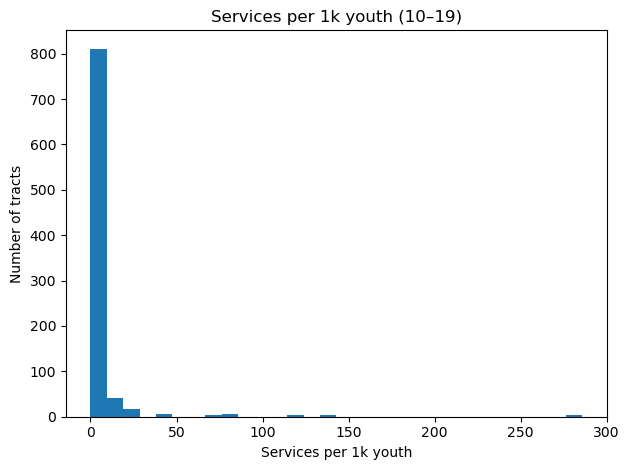

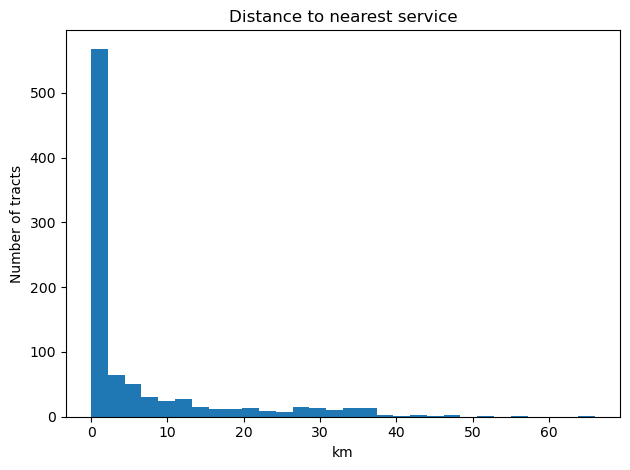

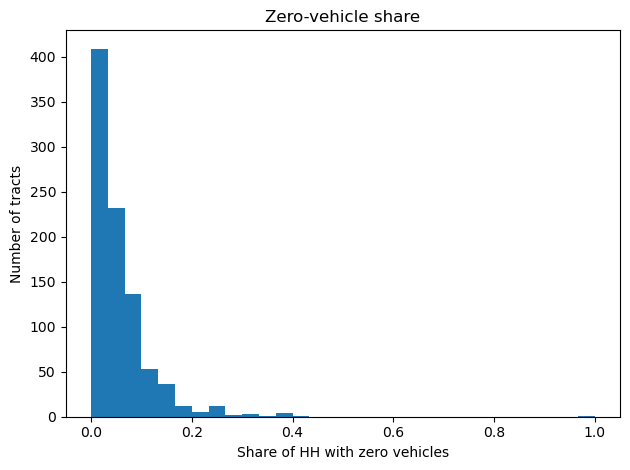

In [68]:
def hist(series, title, xlabel, bins=30):
    plt.figure()
    series.dropna().plot(kind="hist", bins=bins)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Number of tracts")
    plt.tight_layout()
    plt.show()

hist(tract_metrics["services_per_1k_youth_10_19"], "Services per 1k youth (10–19)", "Services per 1k youth")
hist(tract_metrics["avg_distance_to_nearest_service_km"], "Distance to nearest service", "km")
hist(tract_metrics["zero_veh_share"], "Zero-vehicle share", "Share of HH with zero vehicles")


In [69]:
output_path = PROCESSED_ACS_2023_DIR / "tract_opportunity_desert_metrics_2023.csv"
tract_metrics.to_csv(output_path, index=False)
output_path


PosixPath('/Users/laurenvo/Documents/github/Mapping-Youth-Opportunity-Deserts/data/processed/acs5/2023/tract_opportunity_desert_metrics_2023.csv')

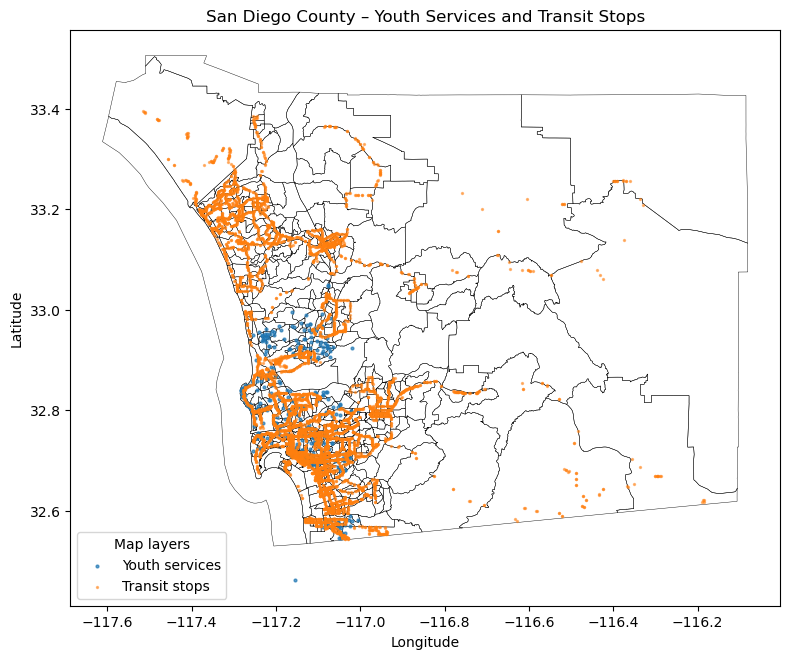

In [70]:
import matplotlib.pyplot as plt

sd_tracts_wgs = sd_tracts_metric.to_crs("EPSG:4326")
services_wgs = services_metric.to_crs("EPSG:4326")
stops_wgs = stops_metric.to_crs("EPSG:4326")

fig, ax = plt.subplots(figsize=(8, 8))

# Tract polygons as background
sd_tracts_wgs.plot(
    ax=ax,
    linewidth=0.3,
    edgecolor="black",
    facecolor="none",
)

# All youth-serving services (dots)
services_wgs.plot(
    ax=ax,
    markersize=4,
    alpha=0.7,
    label="Youth services",
)

# Transit stops (smaller dots)
stops_wgs.plot(
    ax=ax,
    markersize=2,
    alpha=0.5,
    label="Transit stops",
)

ax.set_title("San Diego County – Youth Services and Transit Stops")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Add legend
ax.legend(title="Map layers", loc="lower left")

plt.tight_layout()
plt.show()


In [71]:
pip install contextily

Note: you may need to restart the kernel to use updated packages.


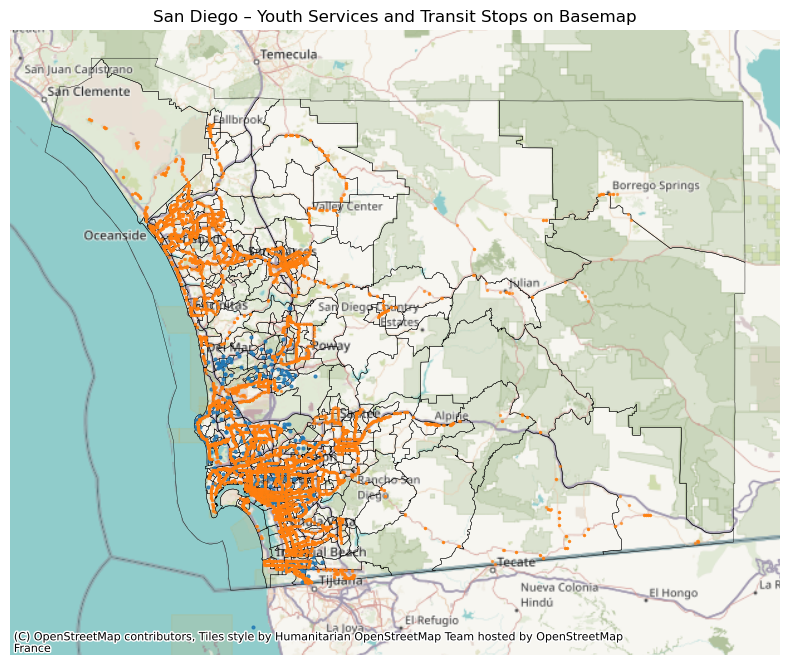

In [72]:
import contextily as ctx

# Web Mercator for basemap tiles
sd_tracts_3857 = sd_tracts_wgs.to_crs("EPSG:3857")
services_3857 = services_wgs.to_crs("EPSG:3857")
stops_3857 = stops_wgs.to_crs("EPSG:3857")

fig, ax = plt.subplots(figsize=(8, 8))

# Plot tracts (outline only so basemap shows through)
sd_tracts_3857.plot(ax=ax, linewidth=0.3, edgecolor="black", facecolor="none")

# Services
services_3857.plot(ax=ax, markersize=4, alpha=0.8)

# Transit stops
stops_3857.plot(ax=ax, markersize=2, alpha=0.6)

# Add basemap underneath
ctx.add_basemap(ax, crs=sd_tracts_3857.crs)

ax.set_title("San Diego – Youth Services and Transit Stops on Basemap")
ax.set_axis_off()
plt.tight_layout()
plt.show()


In [73]:
import geopandas as gpd

# Make sure GEOID is string in both
sd_tracts_metric["GEOID"] = sd_tracts_metric["GEOID"].astype(str)
tract_metrics["GEOID"] = tract_metrics["GEOID"].astype(str)

# Merge geometry + metrics
tracts_deserts = sd_tracts_metric[["GEOID", "geometry"]].merge(
    tract_metrics,
    on="GEOID",
    how="left",
)

# Reproject to WGS84 for easy plotting
tracts_deserts_wgs = tracts_deserts.to_crs("EPSG:4326")

tracts_deserts_wgs.head()


,GEOID,geometry,NAME,pop_total,youth_5_17,youth_10_19,youth_5_17_per_1k,youth_10_19_per_1k,median_hh_income_2023usd,households_total,households_zero_veh,zero_veh_share,services_total,library_count,ymca_count,rec_center_count,youth_org_count,stops_in_tract,stops_within_500m_per_tract,stops_within_500m_of_services,services_within_0_6mi,avg_distance_to_nearest_service_km,distance_to_nearest_library_km,distance_to_nearest_rec_center_km,distance_to_nearest_ymca_km,services_per_1k_youth_10_19,services_per_1k_youth_5_17,stops_within_500m_per_1k_youth,desert_flag
0,06073008331,"POLYGON ((-117.23082 32.94176, -117.23079 32.9...",83.31,2766.0,615.0,556.0,222.342733,201.012292,217083.0,943.0,14.0,0.014846,3,0,0,0,0,0,0,0,7,0.00000,NaN,0.708326,NaN,5.395683,4.878049,0.0,0
1,06073008331,"POLYGON ((-117.23082 32.94176, -117.23079 32.9...",83.31,2766.0,615.0,556.0,222.342733,201.012292,217083.0,943.0,14.0,0.014846,3,0,0,0,0,0,0,0,7,0.00000,NaN,0.708326,NaN,5.395683,4.878049,0.0,0
2,06073008331,"POLYGON ((-117.23082 32.94176, -117.23079 32.9...",83.31,2766.0,615.0,556.0,222.342733,201.012292,217083.0,943.0,14.0,0.014846,3,0,0,0,0,0,0,0,7,0.00000,NaN,0.708326,NaN,5.395683,4.878049,0.0,0
3,06073008336,"POLYGON ((-117.13793 32.96927, -117.13792 32.9...",83.36,2086.0,401.0,294.0,192.233941,140.939597,197841.0,742.0,8.0,0.010782,0,0,0,0,0,0,0,0,1,0.27501,NaN,0.489632,NaN,0.000000,0.000000,0.0,0
4,06073008337,"POLYGON ((-117.14678 32.95497, -117.14657 32.9...",83.37,4996.0,875.0,677.0,175.140112,135.508407,180496.0,1510.0,0.0,0.000000,1,0,0,0,0,0,0,0,1,0.00000,NaN,0.850136,NaN,1.477105,1.142857,0.0,0


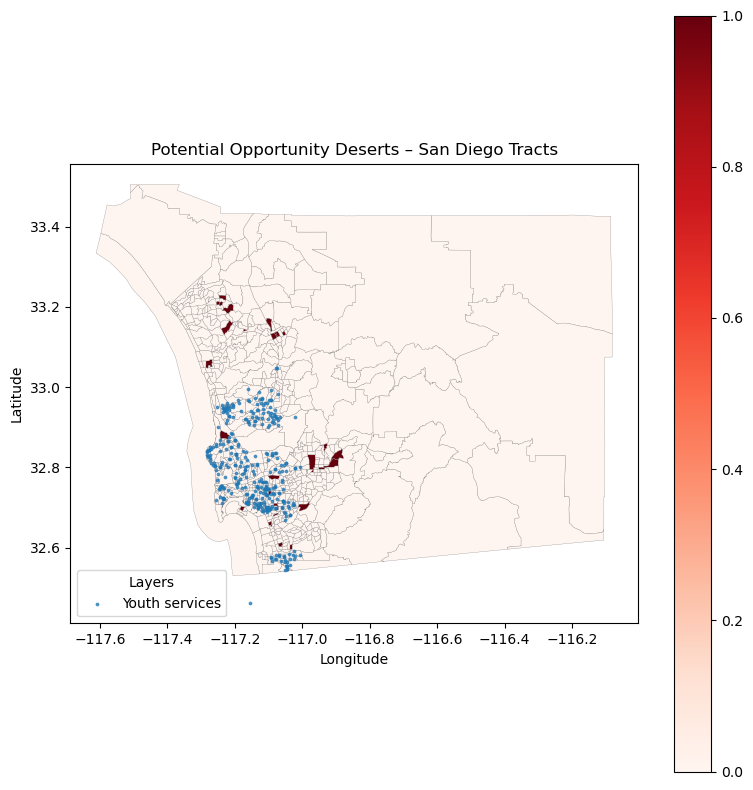

In [74]:
import matplotlib.pyplot as plt

# Reuse your services_wgs from before, or rebuild:
services_df = services.dropna(subset=["lat", "lon"]).copy()
services_wgs = gpd.GeoDataFrame(
    services_df,
    geometry=gpd.points_from_xy(services_df["lon"], services_df["lat"]),
    crs="EPSG:4326",
)

fig, ax = plt.subplots(figsize=(8, 8))

# 0/1 desert flag as choropleth
tracts_deserts_wgs.plot(
    ax=ax,
    column="desert_flag",
    cmap="Reds",          # 0 = light, 1 = dark red
    legend=True,
    edgecolor="grey",
    linewidth=0.2,
)

# Optional: overlay all youth services as small points
services_wgs.plot(
    ax=ax,
    markersize=3,
    alpha=0.7,
    label="Youth services",
)

ax.set_title("Potential Opportunity Deserts – San Diego Tracts")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Legend for the points
ax.legend(title="Layers", loc="lower left")

plt.tight_layout()
plt.show()


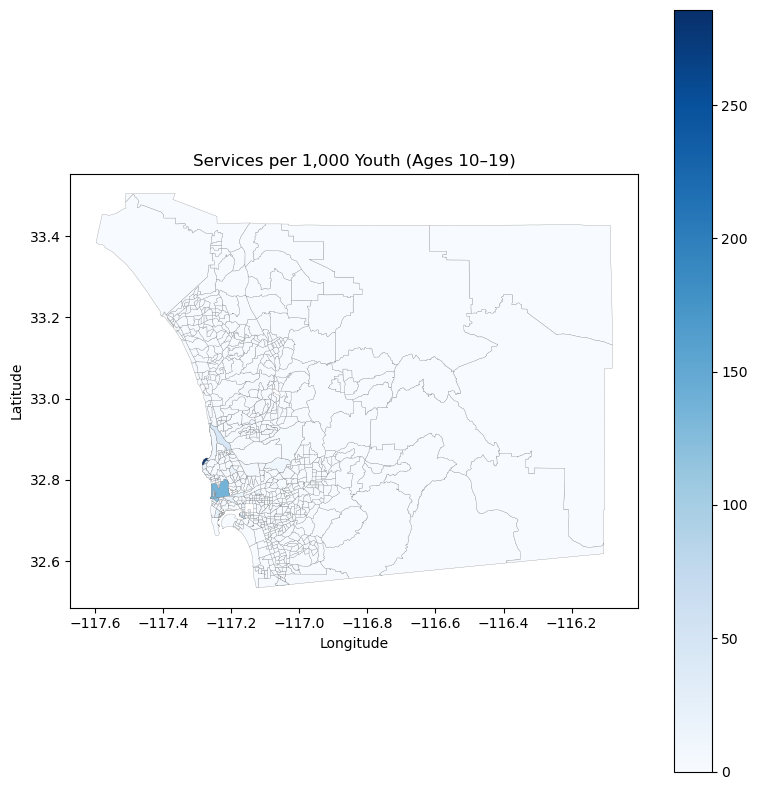

In [75]:
fig, ax = plt.subplots(figsize=(8, 8))

tracts_deserts_wgs.plot(
    ax=ax,
    column="services_per_1k_youth_10_19",
    cmap="Blues",
    legend=True,
    edgecolor="grey",
    linewidth=0.2,
)

ax.set_title("Services per 1,000 Youth (Ages 10–19)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()


/var/folders/dg/bllrnyzj2fzf93_myxywvnnm0000gn/T/ipykernel_21715/4139734453.py:46: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(title="Layers", loc="lower left")


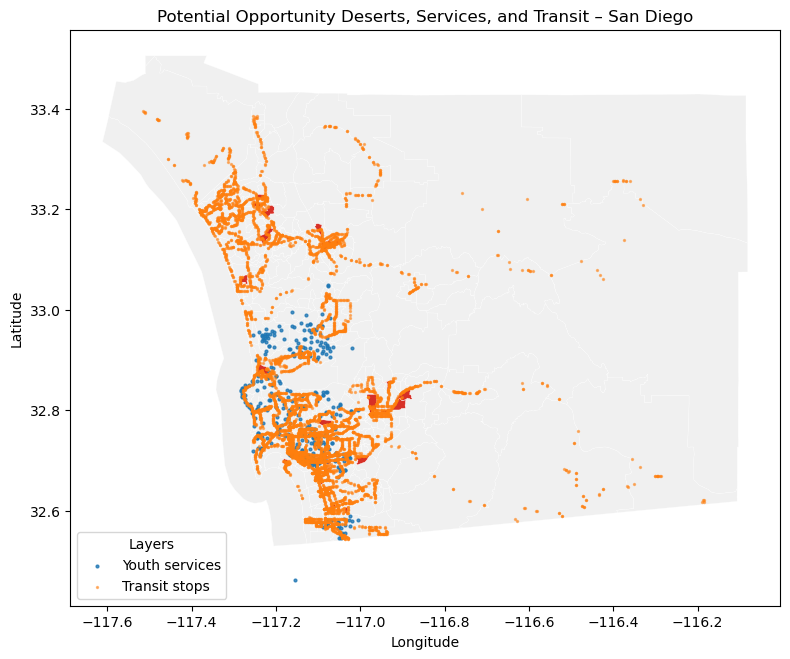

In [76]:
# Split tracts into deserts vs non-deserts
deserts = tracts_deserts_wgs[tracts_deserts_wgs["desert_flag"] == 1]
non_deserts = tracts_deserts_wgs[tracts_deserts_wgs["desert_flag"] == 0]

stops_wgs = stops_metric.to_crs("EPSG:4326")

fig, ax = plt.subplots(figsize=(8, 8))

# Non-desert tracts in light grey
non_deserts.plot(
    ax=ax,
    facecolor="#f0f0f0",
    edgecolor="white",
    linewidth=0.2,
)

# Desert tracts in red
deserts.plot(
    ax=ax,
    facecolor="#d73027",
    edgecolor="white",
    linewidth=0.3,
    label="Desert tracts",
)

# Services
services_wgs.plot(
    ax=ax,
    markersize=4,
    alpha=0.8,
    label="Youth services",
)

# Transit stops
stops_wgs.plot(
    ax=ax,
    markersize=2,
    alpha=0.5,
    label="Transit stops",
)

ax.set_title("Potential Opportunity Deserts, Services, and Transit – San Diego")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.legend(title="Layers", loc="lower left")

plt.tight_layout()
plt.show()


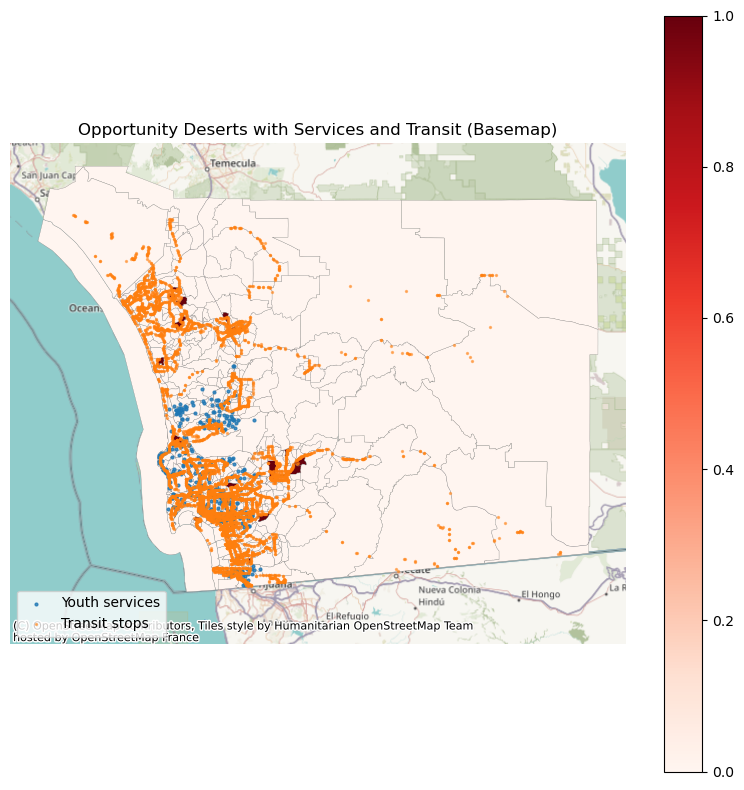

In [77]:
import contextily as ctx

# Convert to Web Mercator
deserts_3857 = tracts_deserts_wgs.to_crs("EPSG:3857")
services_3857 = services_wgs.to_crs("EPSG:3857")
stops_3857 = stops_wgs.to_crs("EPSG:3857")

fig, ax = plt.subplots(figsize=(8, 8))

deserts_3857.plot(
    ax=ax,
    column="desert_flag",
    cmap="Reds",
    legend=True,
    edgecolor="grey",
    linewidth=0.2,
)

services_3857.plot(ax=ax, markersize=4, alpha=0.8, label="Youth services")
stops_3857.plot(ax=ax, markersize=2, alpha=0.5, label="Transit stops")

ctx.add_basemap(ax, crs=deserts_3857.crs)

ax.set_axis_off()
ax.set_title("Opportunity Deserts with Services and Transit (Basemap)")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()


In [78]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

tracts_deserts_wgs = tracts_deserts.to_crs("EPSG:4326")

deserts = tracts_deserts_wgs[tracts_deserts_wgs["desert_flag"] == 1]
non_deserts = tracts_deserts_wgs[tracts_deserts_wgs["desert_flag"] == 0]

services_df = services.dropna(subset=["lat", "lon"]).copy()
services_wgs = gpd.GeoDataFrame(
    services_df,
    geometry=gpd.points_from_xy(services_df["lon"], services_df["lat"]),
    crs="EPSG:4326",
)

stops_wgs = stops_metric.to_crs("EPSG:4326")


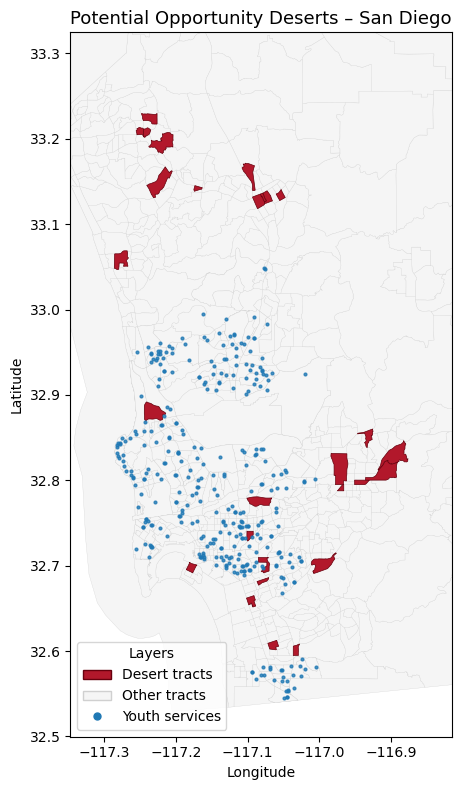

In [79]:
fig, ax = plt.subplots(figsize=(8, 8))

# Plot non-desert tracts in light grey
if not non_deserts.empty:
    non_deserts.plot(
        ax=ax,
        facecolor="#f5f5f5",
        edgecolor="#d0d0d0",
        linewidth=0.2,
    )

# Plot desert tracts in strong red
if not deserts.empty:
    deserts.plot(
        ax=ax,
        facecolor="#b2182b",
        edgecolor="#67000d",
        linewidth=0.5,
    )

# Plot youth services as blue dots
services_wgs.plot(
    ax=ax,
    markersize=4,
    alpha=0.8,
    color="#1f78b4",
)

# # Plot transit stops as small grey dots
# stops_wgs.plot(
#     ax=ax,
#     markersize=2,
#     alpha=0.4,
#     color="#636363",
# )

ax.set_title("Potential Opportunity Deserts – San Diego", fontsize=13)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Zoom in around the desert tracts 
if not deserts.empty:
    xmin, ymin, xmax, ymax = deserts.total_bounds
    pad_x = (xmax - xmin) * 0.15
    pad_y = (ymax - ymin) * 0.15
    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

# Legend
desert_patch = mpatches.Patch(facecolor="#b2182b", edgecolor="#67000d", label="Desert tracts")
nondesert_patch = mpatches.Patch(facecolor="#f5f5f5", edgecolor="#d0d0d0", label="Other tracts")
services_marker = plt.Line2D(
    [], [], marker="o", linestyle="", color="#1f78b4", markersize=5, label="Youth services"
)
# stops_marker = plt.Line2D(
#     [], [], marker="o", linestyle="", color="#636363", markersize=4, label="Transit stops"
# )

ax.legend(
    handles=[desert_patch, nondesert_patch, services_marker],  # add stops_marker if you plot stops
    title="Layers",
    loc="lower left",
    frameon=True,
)

plt.tight_layout()
plt.show()
